# Figure 5: MD simulations and ML predictor comparison

Safe peptides vs activity cliffs, side by side.

**Layout:** 4 rows x 2 columns
- Row 1 (a, b): S-score split violins (MD)
- Row 2 (c, d): AUC heatmap across MD descriptors and simulation blocks
- Row 3 (e, f): ZP-score AUC bars, negative vs positive displacement
- Row 4 (g, h): ML regressor MIC distributions, box + strip plots

Left column = safe peptides (diverse active/inactive), right column = activity cliffs.

MD data from all-atom simulations (500 ns, DPPC bilayer, dual trajectories).
ML data from BATTLE-AMP benchmark predictions.

**Per-panel stories:**
- **(a,b)** S-scores separate active from inactive on safe peptides but collapse on activity cliffs.
- **(c,d)** Terminal helicity and burial metrics drive MD discrimination on safe peptides; no descriptor rescues cliffs.
- **(e,f)** Membrane thinning (ZP-) predicts activity on safe peptides but fails on cliffs.
- **(g,h)** ML regressors show strong MIC separation on safe peptides; heavy overlap on cliffs mirrors MD failure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## Load data

In [2]:
# ── MD data ──────────────────────────────────────────────────────────
MD_DIR = Path("../md")

safe = pd.read_csv(MD_DIR / "safe" / "summary_aa_dual.csv")
paired = pd.read_csv(MD_DIR / "paired" / "summary_aa_dual.csv")

# Average the two trajectory samples (dn, up) per sequence/metric/step
safe_avg = (
    safe.groupby(["sequence", "is_active", "metric", "step"])["value"]
    .mean().reset_index()
)
paired_avg = (
    paired.groupby(["sequence", "is_active", "metric", "step"])["value"]
    .mean().reset_index()
)

print(f"Safe peptides: {safe_avg['sequence'].nunique()} sequences, "
      f"{safe_avg['metric'].nunique()} metrics")
print(f"Paired peptides: {paired_avg['sequence'].nunique()} sequences, "
      f"{paired_avg['metric'].nunique()} metrics")

Safe peptides: 36 sequences, 44 metrics
Paired peptides: 92 sequences, 44 metrics


In [6]:
# ── ML data (produced by: snakemake extract_md_predictions) ────────
RESULTS_DIR = Path("../results/aggregated")

safe_ml = pd.read_csv(RESULTS_DIR / "control-md_predictions.tsv", sep="\t")
y_safe = (safe_ml["true_class"] == "AMP").values
print(f"ML control peptides: {len(safe_ml)} ({y_safe.sum()} active, "
      f"{(~y_safe).sum()} inactive)")

paired_gt = pd.read_csv("../md/activity-cliffs.tsv", sep="\t")
paired_gt["MIC_clean"] = paired_gt["MIC [ug/ml]"].astype(str).str.replace(",", "").astype(float)
paired_pred = pd.read_csv(
    RESULTS_DIR / "activity-cliffs_predictions.tsv", sep="\t"
)

# Build activity labels: sequence -> is_active
pair_labels = {}
n_pairs = len(paired_gt) // 2
for i in range(n_pairs):
    pair_labels[paired_gt.iloc[2 * i]["sequence"].upper()] = True
    pair_labels[paired_gt.iloc[2 * i + 1]["sequence"].upper()] = False
print(f"Activity cliff pairs: {n_pairs}")

ML control peptides: 40 (20 active, 20 inactive)
Activity cliff pairs: 50


## Style and constants

In [7]:
# Journal specs: max 6.5 x 8 in, min fontsize 6, 600 dpi.
# No em dashes.

matplotlib.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"],
    "mathtext.default": "regular",
    "figure.facecolor": "white",
    "axes.facecolor": "#E0E0E0",
    "axes.edgecolor": "#666666",
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.4,
    "ytick.major.width": 0.4,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "axes.grid": False,
})

# MD colors
ACTIVE_COLOR_MD = "#4878A8"
INACTIVE_COLOR_MD = "#C06040"
STEPS = [1, 2, 3, 4, 5]

# ML colors (match the MD active/inactive palette)
ACTIVE_COLOR_ML = "#F7CF8B"
INACTIVE_COLOR_ML = "#66BDBA"

GRID_COLOR = "#dddddd"

# Selected ML regressors for panels g, h
ML_MODELS = [
    ("sensexamp-ecoli", "sensexamp-ecoli_MIC", "sAMPpred$_{EC}$"),
    ("mbc-attention", "mbc-attention_MIC", "MBC-Att."),
    ("sensexamp-saureus", "sensexamp-saureus_MIC", "sAMPpred$_{SA}$"),
    ("ampredictor", "ampredictor_MIC", "AMPredictor"),
    ("apex-min", "apex-min_MIC", "APEX$_{min}$"),
]

## Helper functions

In [8]:
# ── MD panel functions ───────────────────────────────────────────────

def plot_split_violins(ax, df, metric_col="S", ylabel="S-score", title=""):
    """Split violin plot: active vs inactive across simulation blocks."""
    data = df[df["metric"] == metric_col].copy()
    data["Status"] = data["is_active"].map({1: "Active", 0: "Inactive"})
    steps = sorted(data["step"].unique())

    for status, offset, color in [
        ("Active", -0.17, ACTIVE_COLOR_MD),
        ("Inactive", 0.17, INACTIVE_COLOR_MD),
    ]:
        subset = data[data["Status"] == status]
        data_by_step = [
            subset[subset["step"] == s]["value"].dropna().values for s in steps
        ]
        if all(len(d) == 0 for d in data_by_step):
            continue
        positions = np.array(steps) + offset
        vp = ax.violinplot(
            data_by_step, positions=positions,
            widths=0.3, showmedians=True, showextrema=False,
        )
        for body in vp["bodies"]:
            body.set_facecolor(color)
            body.set_alpha(0.65)
            body.set_edgecolor("black")
            body.set_linewidth(0.3)
            m = np.mean(body.get_paths()[0].vertices[:, 0])
            if offset < 0:
                body.get_paths()[0].vertices[:, 0] = np.clip(
                    body.get_paths()[0].vertices[:, 0], -np.inf, m)
            else:
                body.get_paths()[0].vertices[:, 0] = np.clip(
                    body.get_paths()[0].vertices[:, 0], m, np.inf)
        vp["cmedians"].set_color("black")
        vp["cmedians"].set_linewidth(0.5)

    for yval in np.arange(0, 1.1, 0.2):
        ax.axhline(y=yval, color="white", linewidth=0.4, zorder=0)

    ax.set_xticks(steps)
    ax.set_xticklabels([str(s) for s in steps])
    ax.set_xlabel("Simulation block (100 ns each)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlim(0.4, 5.6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def compute_auc_matrix(df, metrics, steps):
    """Compute AUC for each metric/step, direction-corrected."""
    matrix = np.full((len(steps), len(metrics)), np.nan)
    for j, metric in enumerate(metrics):
        for i, step in enumerate(steps):
            subset = df[(df["metric"] == metric) & (df["step"] == step)]
            if len(subset) < 5 or len(np.unique(subset["is_active"])) < 2:
                continue
            try:
                matrix[i, j] = roc_auc_score(
                    subset["is_active"].values, subset["value"].values)
            except Exception:
                pass
    # Direction-correct: if mean AUC < 0.5, flip
    for j in range(len(metrics)):
        col = matrix[:, j]
        valid = col[~np.isnan(col)]
        if len(valid) > 0 and np.mean(valid) < 0.5:
            matrix[:, j] = 1.0 - col
    return matrix


def plot_auc_heatmap(ax, matrix, metrics, steps, title="",
                     vmin=0.35, vmax=0.90, metric_labels=None):
    """AUC heatmap with cell annotations."""
    im = ax.imshow(
        matrix, cmap="RdYlGn", aspect="auto",
        vmin=vmin, vmax=vmax, interpolation="nearest",
    )
    for i in range(len(steps)):
        for j in range(len(metrics)):
            val = matrix[i, j]
            if not np.isnan(val):
                color = "white" if val > 0.82 or val < 0.42 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color=color)

    labels = metric_labels if metric_labels else metrics
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(labels, fontsize=6, ha="center", rotation=0)
    ax.set_yticks(range(len(steps)))
    ax.set_yticklabels([f"Block {s}" for s in steps])
    ax.set_title(title, loc="left", fontweight="bold")
    return im


def plot_zp_bars(ax, df, step, title="", show_legend=True):
    """Paired bar chart: ZP-negative vs ZP-positive AUC."""
    zp_neg = [f"ZP-{b}" for b in
              ["0.5", "1.5", "2.5", "3.5", "4.5",
               "5.5", "6.5", "7.5", "8.5", "9.5"]]
    zp_pos = [f"ZP{b}" for b in
              ["0.5", "1.5", "2.5", "3.5", "4.5",
               "5.5", "6.5", "7.5", "8.5", "9.5"]]

    def get_aucs(bins):
        aucs = []
        for metric in bins:
            subset = df[(df["metric"] == metric) & (df["step"] == step)]
            if len(subset) < 5 or len(np.unique(subset["is_active"])) < 2:
                aucs.append(np.nan)
                continue
            try:
                aucs.append(roc_auc_score(
                    subset["is_active"].values, subset["value"].values))
            except Exception:
                aucs.append(np.nan)
        return aucs

    aucs_neg = get_aucs(zp_neg)
    aucs_pos = get_aucs(zp_pos)

    x = np.arange(len(zp_neg))
    width = 0.35

    ax.bar(x - width / 2, aucs_neg, width, color=ACTIVE_COLOR_MD, alpha=0.75,
           edgecolor="black", linewidth=0.3,
           label="ZP negative (membrane thinning)")
    ax.bar(x + width / 2, aucs_pos, width, color=INACTIVE_COLOR_MD, alpha=0.75,
           edgecolor="black", linewidth=0.3,
           label="ZP positive (membrane thickening)")

    ax.axhline(y=0.5, color="black", linewidth=0.6, linestyle="--", alpha=0.6)
    for yval in [0.3, 0.4, 0.6, 0.7, 0.8]:
        ax.axhline(y=yval, color="white", linewidth=0.4, zorder=0)

    bin_values = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.1f}" for v in bin_values], fontsize=6)
    ax.set_xlabel("Phosphate displacement magnitude (\u00c5)")
    ax.set_ylabel("AUC")
    ax.set_ylim(0.15, 0.92)
    ax.set_title(title, loc="left", fontweight="bold")
    if show_legend:
        ax.legend(loc="upper left", frameon=True, facecolor="white",
                  edgecolor="none", framealpha=0.9, fontsize=6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


# ── ML panel function ────────────────────────────────────────────────

def plot_ml_boxes(ax, data_dict, models, title=""):
    """Box + strip plot: active vs inactive log2(MIC) for selected regressors.

    Parameters
    ----------
    data_dict : dict  model_key -> (active_array, inactive_array)
    models : list of (model_key, col, display_name)
    """
    n = len(models)
    pos_a = np.arange(n) - 0.18
    pos_i = np.arange(n) + 0.18
    bw = 0.30

    for idx, (mkey, _, display) in enumerate(models):
        active, inactive = data_dict.get(mkey, ([], []))
        if len(active) == 0 or len(inactive) == 0:
            continue

        a_log = np.log2(np.clip(active, 0.01, None))
        i_log = np.log2(np.clip(inactive, 0.01, None))

        for vals, pos, color in [
            (a_log, pos_a[idx], ACTIVE_COLOR_ML),
            (i_log, pos_i[idx], INACTIVE_COLOR_ML),
        ]:
            ax.boxplot(
                [vals], positions=[pos], widths=bw,
                patch_artist=True, showfliers=False, zorder=2,
                boxprops=dict(facecolor=color, edgecolor="black",
                              linewidth=0.4, alpha=0.7),
                medianprops=dict(color="black", linewidth=0.8),
                whiskerprops=dict(color="black", linewidth=0.4),
                capprops=dict(color="black", linewidth=0.4),
            )
            jitter = np.random.normal(0, 0.04, len(vals))
            ax.scatter(
                pos + jitter, vals, s=6, color=color,
                edgecolor="black", linewidth=0.2, alpha=0.8, zorder=3,
            )

    ax.set_xticks(np.arange(n))
    ax.set_xticklabels([m[2] for m in models], fontsize=6,
                       rotation=35, ha="right")
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylabel("$\\log_2$ MIC")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.yaxis.grid(True, color="white", linewidth=0.4)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

## Prepare ML data

In [9]:
# ── Safe peptides: extract MIC scores per model ─────────────────────
ml_safe_data = {}
for mkey, col, display in ML_MODELS:
    mask = safe_ml[col].notna()
    vals = safe_ml.loc[mask, col].values
    labels = y_safe[mask.values]
    ml_safe_data[mkey] = (vals[labels], vals[~labels])

# ── Activity cliffs: extract MIC scores per model ───────────────────
ml_cliff_data = {}
for mkey, _, display in ML_MODELS:
    sub = paired_pred[
        (paired_pred["variant"] == mkey) & paired_pred["MIC"].notna()
    ]
    active_mics, inactive_mics = [], []
    for _, r in sub.iterrows():
        seq = str(r["sequence"]).upper()
        if seq in pair_labels:
            if pair_labels[seq]:
                active_mics.append(r["MIC"])
            else:
                inactive_mics.append(r["MIC"])
    ml_cliff_data[mkey] = (np.array(active_mics), np.array(inactive_mics))

print("ML data prepared:")
for mkey, _, display in ML_MODELS:
    a_s, i_s = ml_safe_data[mkey]
    a_c, i_c = ml_cliff_data[mkey]
    print(f"  {display:20s}  safe: {len(a_s)}+{len(i_s)}  "
          f"cliffs: {len(a_c)}+{len(i_c)}")

ML data prepared:
  sAMPpred$_{EC}$       safe: 18+20  cliffs: 45+43
  MBC-Att.              safe: 20+20  cliffs: 49+46
  sAMPpred$_{SA}$       safe: 18+20  cliffs: 45+43
  AMPredictor           safe: 20+20  cliffs: 49+46
  APEX$_{min}$          safe: 20+20  cliffs: 49+46


## Build figure

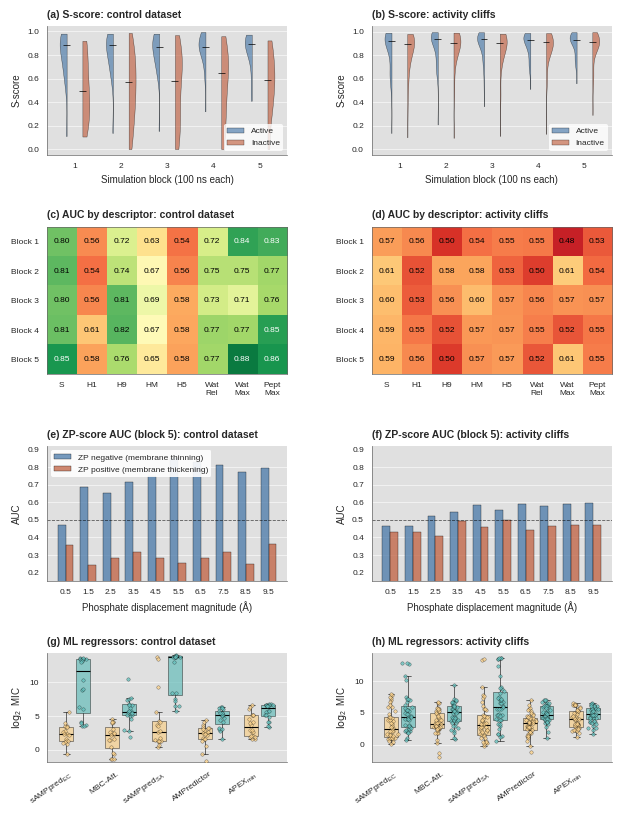

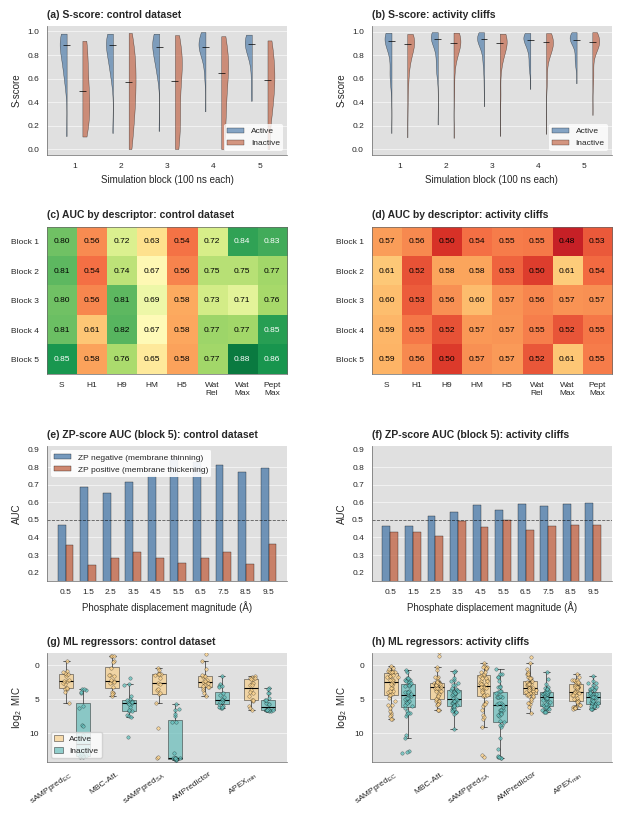

Saved to ../figures/figure5.png and .pdf


In [12]:
np.random.seed(42)

fig = plt.figure(figsize=(6.5, 8.0))
gs = gridspec.GridSpec(
    4, 2, hspace=0.55, wspace=0.35,
    left=0.09, right=0.96, top=0.97, bottom=0.05,
    height_ratios=[1, 1.15, 1.05, 0.85],
)

# ── Legend handles for MD panels ─────────────────────────────────────
LEGEND_MD = [
    Patch(facecolor=ACTIVE_COLOR_MD, alpha=0.65, edgecolor="black",
          linewidth=0.3, label="Active"),
    Patch(facecolor=INACTIVE_COLOR_MD, alpha=0.65, edgecolor="black",
          linewidth=0.3, label="Inactive"),
]

# ── Row 1: S-score violins ──────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
plot_split_violins(ax_a, safe_avg, "S", "S-score",
                   "(a) S-score: control dataset")
ax_a.legend(handles=LEGEND_MD, loc="lower right",
            frameon=True, facecolor="white", edgecolor="none",
            framealpha=0.8)

ax_b = fig.add_subplot(gs[0, 1])
plot_split_violins(ax_b, paired_avg, "S", "S-score",
                   "(b) S-score: activity cliffs")
ax_b.legend(handles=LEGEND_MD, loc="lower right",
            frameon=True, facecolor="white", edgecolor="none",
            framealpha=0.8)

# ── Row 2: AUC heatmaps ────────────────────────────────────────────
h_metrics = ["S", "H1", "H9", "HM", "H5",
             "WAT_BUR_REL", "WAT_BUR_MAX", "PEPT_BUR_MAX"]
metric_labels = ["S", "H1", "H9", "HM", "H5",
                 "Wat\nRel", "Wat\nMax", "Pept\nMax"]

safe_auc = compute_auc_matrix(safe_avg, h_metrics, STEPS)
paired_auc = compute_auc_matrix(paired_avg, h_metrics, STEPS)

all_auc_vals = np.concatenate([
    safe_auc[~np.isnan(safe_auc)],
    paired_auc[~np.isnan(paired_auc)],
])
vmin_shared = max(0.35, np.floor(all_auc_vals.min() * 20) / 20)
vmax_shared = min(0.92, np.ceil(all_auc_vals.max() * 20) / 20)

ax_c = fig.add_subplot(gs[1, 0])
plot_auc_heatmap(ax_c, safe_auc, h_metrics, STEPS,
                 "(c) AUC by descriptor: control dataset",
                 vmin=vmin_shared, vmax=vmax_shared,
                 metric_labels=metric_labels)

ax_d = fig.add_subplot(gs[1, 1])
plot_auc_heatmap(ax_d, paired_auc, h_metrics, STEPS,
                 "(d) AUC by descriptor: activity cliffs",
                 vmin=vmin_shared, vmax=vmax_shared,
                 metric_labels=metric_labels)

# ── Row 3: ZP-score bars ───────────────────────────────────────────
ax_e = fig.add_subplot(gs[2, 0])
plot_zp_bars(ax_e, safe_avg, step=5,
             title="(e) ZP-score AUC (block 5): control dataset")

ax_f = fig.add_subplot(gs[2, 1])
plot_zp_bars(ax_f, paired_avg, step=5,
             title="(f) ZP-score AUC (block 5): activity cliffs",
             show_legend=False)

# ── Row 4: ML regressor box + strip plots ──────────────────────────
ax_g = fig.add_subplot(gs[3, 0])
plot_ml_boxes(ax_g, ml_safe_data, ML_MODELS,
              title="(g) ML regressors: control dataset")

ax_h = fig.add_subplot(gs[3, 1])
plot_ml_boxes(ax_h, ml_cliff_data, ML_MODELS,
              title="(h) ML regressors: activity cliffs")

# Shared y-axis for ML panels
all_ml = []
for d in [ml_safe_data, ml_cliff_data]:
    for a, i in d.values():
        if len(a) > 0:
            all_ml.extend(np.log2(np.clip(a, 0.01, None)))
        if len(i) > 0:
            all_ml.extend(np.log2(np.clip(i, 0.01, None)))
ymin_ml = np.percentile(all_ml, 0.5) - 0.5
ymax_ml = np.percentile(all_ml, 99.5) + 0.5
ax_g.set_ylim(ymin_ml, ymax_ml)
ax_h.set_ylim(ymin_ml, ymax_ml)
# Invert: lower MIC (more potent) at top
ax_g.invert_yaxis()
ax_h.invert_yaxis()

# ML legend
ml_handles = [
    Patch(facecolor=ACTIVE_COLOR_ML, edgecolor="black",
          linewidth=0.4, alpha=0.7, label="Active"),
    Patch(facecolor=INACTIVE_COLOR_ML, edgecolor="black",
          linewidth=0.4, alpha=0.7, label="Inactive"),
]
ax_g.legend(handles=ml_handles, fontsize=6, loc="lower left",
            frameon=True, facecolor="white", edgecolor="#cccccc",
            handlelength=1.0, handleheight=0.7)

# ── Save ────────────────────────────────────────────────────────────
fig.savefig("../figures/figure5.png", dpi=600,
            bbox_inches="tight", facecolor="white")
fig.savefig("../figures/figure5.pdf", dpi=600,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved to ../figures/figure5.png and .pdf")

## Alt text

**Figure 5.** MD simulations and ML predictor comparison on safe peptides (left) and activity cliffs (right).
**(a, b)** Split violin plots of MD-derived S-scores across five 100 ns simulation blocks.
Active (blue) and inactive (orange) peptides show clear separation on safe peptides (a)
but overlap heavily on activity cliffs (b).
**(c, d)** AUC heatmaps for eight MD descriptors (S-score, helicity H1/H5/H9/HM,
water burial, peptide burial) across simulation blocks. Safe peptides (c) show
discriminative power (AUC 0.65-0.85) for S, H1, H9, and burial metrics;
activity cliffs (d) hover near chance (0.45-0.55) for all descriptors.
**(e, f)** ZP-score AUC for membrane thinning (ZP-) and thickening (ZP+) at
ten displacement magnitude bins (block 5). Safe peptides (e) show ZP- AUC
reaching 0.75-0.80 at large displacements; activity cliffs (f) show no
discriminative signal.
**(g, h)** ML regressor predicted MIC distributions (log2 scale, inverted y-axis)
for five selected models. Box plots with individual data points overlaid.
Active (yellow) vs inactive (teal). Safe peptides (g) show strong separation
for SenseXAMP and MBC-Attention; activity cliffs (h) show heavily overlapping
distributions across all models, mirroring the MD failure pattern.